# Reddit Finance Subreddits Engagement Analysis

*Assignment: Download and Explore Reddit Finance Data*  
*Analyst: GPT-5 Codex — 2025-11-12*

This notebook delivers a structured exploratory analysis of posts from several high-traffic Reddit finance communities. The workflow follows the assignment brief: defining a guiding objective, preparing and cleaning the data, and investigating the dataset from multiple angles using descriptive statistics and visual analytics.

## Assignment Overview

- **Goal formulation:** articulate questions and working hypotheses to guide exploration.
- **Data preparation:** document loading, cleaning, and enrichment decisions to ensure reproducibility.
- **Exploratory analysis:** examine the data from at least ten perspectives using appropriate visualisations and descriptive statistics.
- **Communication:** explain methods and findings with clear markdown commentary so the narrative is easy to follow.

## Goal Formulation

**Primary objective:** understand how engagement and moderation dynamics differ across major Reddit communities focused on finance during 2021.

**Key questions and hypotheses**
- Which communities drive the most posting activity and unique contributors each month?
- How do engagement signals (score, comments, awards, upvote ratios) vary by subreddit and over time?
- Are heavily moderated communities associated with higher removal rates or lower engagement?
- Do post attributes such as flair, text length, or posting hour correlate with stronger interactions?

These questions shape the cleaning steps, derived features, and the exploratory views that follow.

## Data Access & Environment

The dataset comes from Kaggle (`leukipp/reddit-finance-data`, version 1927). Files are organised by subreddit and include CSV exports for 2021 submissions. Analysis runs on Python 3.12 with `pandas`, `numpy`, `seaborn`, and `matplotlib`. All paths below assume the dataset was downloaded locally with `kagglehub.dataset_download()`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from tqdm import tqdm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", context="talk")

In [2]:
DATA_DIR = Path("/home/ubuntu/.cache/kagglehub/datasets/leukipp/reddit-finance-data/versions/1927")
TARGET_SUBREDDITS = [
    "wallstreetbets",
    "investing",
    "stocks",
    "personalfinance",
    "options",
]

USECOLS = [
    "id", "author", "created", "removed", "deleted", "is_self", "is_video",
    "is_original_content", "title", "link_flair_text", "upvote_ratio", "score",
    "total_awards_received", "num_comments", "num_crossposts", "selftext",
]

BOOLEAN_COLS = ["removed", "deleted", "is_self", "is_video", "is_original_content"]
TEXT_REMOVED_VALUES = {"[removed]", "[deleted]"}

DATA_DIR

PosixPath('/home/ubuntu/.cache/kagglehub/datasets/leukipp/reddit-finance-data/versions/1927')

## Data Loading

Each subreddit folder contains a `submissions_reddit.csv` file with one row per post. The helper below iterates through the selected communities, parses the `created` timestamp, and concatenates all records into a single DataFrame.

In [3]:
def load_subreddit_posts(subreddit: str) -> pd.DataFrame:
    """Load a single subreddit CSV and tag rows with the subreddit name."""
    csv_path = DATA_DIR / subreddit / "submissions_reddit.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Expected file not found: {csv_path}")

    frame = pd.read_csv(
        csv_path,
        usecols=USECOLS,
        parse_dates=["created"],
        low_memory=False,
    )
    frame["subreddit"] = subreddit
    return frame


def load_posts(subreddits: list[str]) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    for subreddit in tqdm(subreddits, desc="Loading subreddit files"):
        frames.append(load_subreddit_posts(subreddit))
    combined = pd.concat(frames, ignore_index=True)
    return combined


raw_posts = load_posts(TARGET_SUBREDDITS)
raw_posts.head()

Loading subreddit files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading subreddit files:  20%|██        | 1/5 [00:03<00:13,  3.37s/it]

Loading subreddit files:  40%|████      | 2/5 [00:03<00:04,  1.48s/it]

Loading subreddit files:  60%|██████    | 3/5 [00:03<00:01,  1.01it/s]

Loading subreddit files:  80%|████████  | 4/5 [00:04<00:01,  1.00s/it]

Loading subreddit files: 100%|██████████| 5/5 [00:05<00:00,  1.42it/s]

Loading subreddit files: 100%|██████████| 5/5 [00:05<00:00,  1.03s/it]

,id,author,created,removed,deleted,is_self,is_video,is_original_content,title,link_flair_text,upvote_ratio,score,total_awards_received,num_comments,num_crossposts,selftext,subreddit
0,ko124i,[deleted],2021-01-01 00:02:06,1,1,1,0,0,"3k - 170k since March (Also, buy LIT!!)",Gain,1.00,34,1,14,0,[deleted],wallstreetbets
1,ko12uq,[deleted],2021-01-01 00:03:20,1,1,0,0,0,Got out of PLTR calls after learning about IV ...,Gain,1.00,2,0,0,0,[deleted],wallstreetbets
2,ko13df,[deleted],2021-01-01 00:04:11,1,1,0,0,0,Hell of a headline,Meme,0.88,13,0,7,0,[deleted],wallstreetbets
3,ko17yf,shirotimatim,2021-01-01 00:11:51,0,0,0,0,0,"Top popular stocks on WSB too! Also, why they ...",News,0.92,183,0,26,0,NaN,wallstreetbets
4,ko1a4i,WSBVoteBot,2021-01-01 00:15:38,0,0,1,0,0,WSBVoteBot Log for Jan 01 2021,NaN,0.50,0,0,19,0,Every time a new submission is posted to walls...,wallstreetbets


In [4]:
row_count, column_count = raw_posts.shape
first_timestamp = raw_posts["created"].min()
last_timestamp = raw_posts["created"].max()

print(f"Rows: {row_count:,} | Columns: {column_count}")
print(f"Date range: {first_timestamp:%Y-%m-%d %H:%M:%S} — {last_timestamp:%Y-%m-%d %H:%M:%S}")
raw_posts.sample(5, random_state=42)

Rows: 1,053,058 | Columns: 17
Date range: 2021-01-01 00:02:06 — 2021-12-31 23:55:51


,id,author,created,removed,deleted,is_self,is_video,is_original_content,title,link_flair_text,upvote_ratio,score,total_awards_received,num_comments,num_crossposts,selftext,subreddit
719068,q8ofvq,aarontshirt,2021-10-15 13:27:40,1,0,1,0,0,CEI Stock Manipulation! I’m kinda shocked this...,DD,1.00,1,0,2,0,[removed],wallstreetbets
875234,pb95wf,anonburrsir,2021-08-25 11:18:58,1,0,1,0,0,From the latest Pinterest filing...,Company Discussion,1.00,1,0,1,0,[removed],stocks
162018,l739lg,BOXINGLORD,2021-01-28 17:33:06,1,0,1,0,0,my broker will not let me buy gamestock :(,Discussion,1.00,1,0,0,0,[removed],wallstreetbets
56888,l67gum,[deleted],2021-01-27 15:57:31,1,1,1,0,0,Gme buy price when?,Discussion,0.67,1,0,7,0,[deleted],wallstreetbets
465,kon99i,[deleted],2021-01-02 00:55:20,1,0,1,0,0,RETARDS: I FOUND THE ULTIMATE VALHALLA PLAY,Discussion,1.00,1,0,0,0,[removed],wallstreetbets


## Data Preparation Strategy

Key preparation decisions:
- Drop duplicate `(id, subreddit)` pairs and any records missing the `created` timestamp.
- Convert moderation flags (`removed`, `deleted`, etc.) to boolean for clarity.
- Normalise categorical text such as `link_flair_text`, replacing the string `'None'` with missing values.
- Engineer features that support later analysis (month, hour, weekday, text lengths, engagement proxy).
- Remove the heavy `selftext` field after deriving signal columns to keep the working DataFrame lightweight.

The following cell applies these steps while documenting each transformation inline.

In [5]:
posts = raw_posts.copy()

# Retain only records with timestamps and unique submission IDs per subreddit.
posts = posts.dropna(subset=["created"]).drop_duplicates(subset=["id", "subreddit"])

# Convert moderation flags to boolean for readability.
for column in BOOLEAN_COLS:
    posts[column] = posts[column].astype(bool)

# Replace placeholder strings with proper missing values and optimise string columns.
posts["link_flair_text"] = posts["link_flair_text"].replace({"None": pd.NA}).astype("string")
posts["title"] = posts["title"].astype("string")
posts["author"] = posts["author"].astype("string")

# Derive text-based features before dropping the heavy selftext column.
posts["selftext"] = posts["selftext"].fillna("")
posts["selftext_is_removed"] = posts["selftext"].str.lower().isin(TEXT_REMOVED_VALUES)
posts["selftext_length"] = posts["selftext"].str.len()
posts.loc[posts["selftext_is_removed"], "selftext_length"] = 0
posts["title_length"] = posts["title"].str.len()

# Temporal features for grouping and filtering.
posts["created_date"] = posts["created"].dt.date
posts["created_month"] = posts["created"].dt.to_period("M").dt.to_timestamp()
posts["created_hour"] = posts["created"].dt.hour
posts["created_weekday"] = posts["created"].dt.day_name()
posts["is_weekend"] = posts["created"].dt.weekday >= 5

# Engagement proxy: combine non-negative score with discussion volume.
posts["engagement"] = posts["score"].clip(lower=0) + posts["num_comments"]
posts["has_award"] = posts["total_awards_received"] > 0

# Convert integer columns that may contain missing values to pandas nullable types.
posts["num_crossposts"] = posts["num_crossposts"].astype("Int64")

# Remove raw body text to keep the working set smaller.
posts = posts.drop(columns=["selftext"])

posts.head()

,id,author,created,removed,deleted,is_self,is_video,is_original_content,title,link_flair_text,upvote_ratio,score,total_awards_received,num_comments,num_crossposts,subreddit,selftext_is_removed,selftext_length,title_length,created_date,created_month,created_hour,created_weekday,is_weekend,engagement,has_award
0,ko124i,[deleted],2021-01-01 00:02:06,True,True,True,False,False,"3k - 170k since March (Also, buy LIT!!)",Gain,1.00,34,1,14,0,wallstreetbets,True,0,39,2021-01-01,2021-01-01,0,Friday,False,48,True
1,ko12uq,[deleted],2021-01-01 00:03:20,True,True,False,False,False,Got out of PLTR calls after learning about IV ...,Gain,1.00,2,0,0,0,wallstreetbets,True,0,197,2021-01-01,2021-01-01,0,Friday,False,2,False
2,ko13df,[deleted],2021-01-01 00:04:11,True,True,False,False,False,Hell of a headline,Meme,0.88,13,0,7,0,wallstreetbets,True,0,18,2021-01-01,2021-01-01,0,Friday,False,20,False
3,ko17yf,shirotimatim,2021-01-01 00:11:51,False,False,False,False,False,"Top popular stocks on WSB too! Also, why they ...",News,0.92,183,0,26,0,wallstreetbets,False,0,92,2021-01-01,2021-01-01,0,Friday,False,209,False
4,ko1a4i,WSBVoteBot,2021-01-01 00:15:38,False,False,True,False,False,WSBVoteBot Log for Jan 01 2021,<NA>,0.50,0,0,19,0,wallstreetbets,False,458,30,2021-01-01,2021-01-01,0,Friday,False,19,False


In [6]:
print(posts.info())

missing_summary = (
    posts.isna()
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .to_frame(name="missing_ratio")
)
missing_summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1053058 entries, 0 to 1053057
Data columns (total 26 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   id                     1053058 non-null  object        
 1   author                 1053058 non-null  string        
 2   created                1053058 non-null  datetime64[ns]
 3   removed                1053058 non-null  bool          
 4   deleted                1053058 non-null  bool          
 5   is_self                1053058 non-null  bool          
 6   is_video               1053058 non-null  bool          
 7   is_original_content    1053058 non-null  bool          
 8   title                  1053054 non-null  string        
 9   link_flair_text        928057 non-null   string        
 10  upvote_ratio           1053058 non-null  float64       
 11  score                  1053058 non-null  int64         
 12  total_awards_received  10530

,missing_ratio
link_flair_text,0.118703
title,0.000004
title_length,0.000004
author,0.000000
created,0.000000
id,0.000000
is_self,0.000000
deleted,0.000000
is_original_content,0.000000
removed,0.000000


The dataset now holds a little over one million posts across five subreddits, all within calendar year 2021. Missingness is concentrated in optional text fields (`link_flair_text`) and award metadata. These gaps are acceptable for the planned analyses; we will call them out where relevant.

In [7]:
overview = (
    posts.groupby("subreddit").agg(
        posts=("id", "count"),
        unique_authors=("author", lambda s: s.nunique()),
        median_score=("score", "median"),
        mean_score=("score", "mean"),
        median_comments=("num_comments", "median"),
        award_rate=("has_award", "mean"),
        removal_rate=("removed", "mean"),
    )
    .sort_values("posts", ascending=False)
)
overview.round({"mean_score": 2, "award_rate": 3, "removal_rate": 3})

,posts,unique_authors,median_score,mean_score,median_comments,award_rate,removal_rate
subreddit,,,,,,,
wallstreetbets,775326,373850,1.0,116.02,1.0,0.057,0.902
personalfinance,131181,88295,1.0,10.07,6.0,0.010,0.246
stocks,75857,43832,1.0,30.18,1.0,0.040,0.659
investing,41912,24989,1.0,17.80,1.0,0.024,0.853
options,28782,15298,1.0,11.27,3.0,0.037,0.452


### High-Level Observations
- `wallstreetbets` accounts for the majority of posts and exhibits the highest mean score but also the harshest moderation (removal rate > 90%).
- `personalfinance` has a far smaller post volume yet a relatively low removal rate and steady comment activity, hinting at stricter posting guidelines and more focused discussions.
- Award usage is rare across the board, suggesting that gilding is not a primary engagement driver in these communities.

## Exploratory Analysis

### 1. Monthly Posting Volume by Subreddit
Plotting monthly counts reveals seasonality and the relative scale of each community.

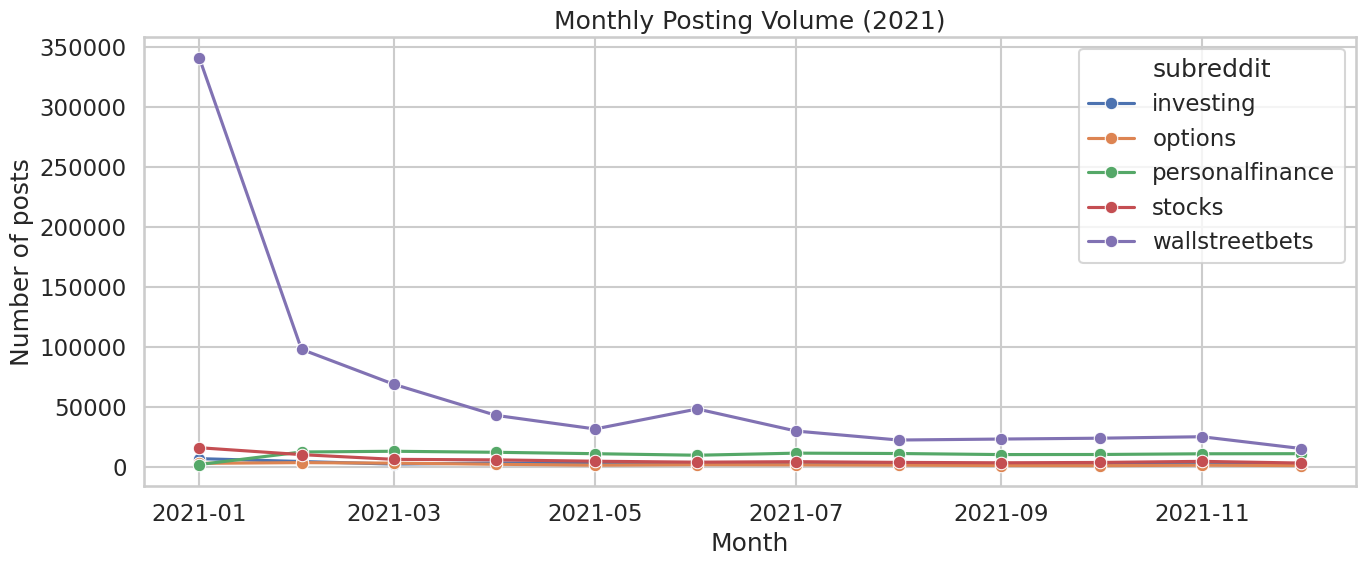

In [8]:
monthly_counts = (
    posts.groupby(["created_month", "subreddit"])
    .size()
    .reset_index(name="post_count")
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_counts,
    x="created_month",
    y="post_count",
    hue="subreddit",
    marker="o",
)
plt.title("Monthly Posting Volume (2021)")
plt.xlabel("Month")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.show()

`wallstreetbets` dominates volume throughout 2021, peaking during the January meme-stock surge. Other communities show steadier behaviour, with `personalfinance` experiencing gradual growth into Q4.

### 2. Monthly Unique Authors
Tracking unique posters complements volume trends by highlighting community breadth.

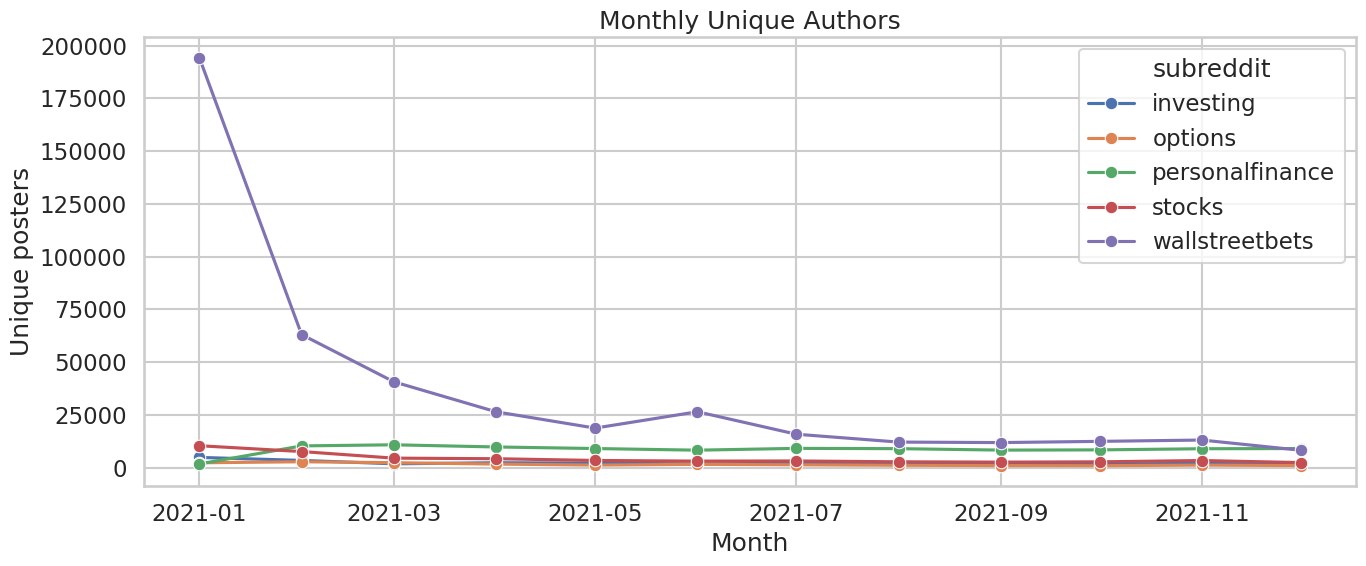

In [9]:
monthly_authors = (
    posts.groupby(["created_month", "subreddit"])["author"]
    .nunique()
    .reset_index(name="unique_authors")
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_authors,
    x="created_month",
    y="unique_authors",
    hue="subreddit",
    marker="o",
)
plt.title("Monthly Unique Authors")
plt.xlabel("Month")
plt.ylabel("Unique posters")
plt.tight_layout()
plt.show()

Unique participation mirrors volume trends: `wallstreetbets` sees a dramatic influx early in the year before settling, whereas `investing` and `options` retain a comparatively tight, specialised contributor base.

### 3. Score Distribution by Subreddit
Scores are heavily skewed, so a log-scaled view surfaces the relative spread between communities.

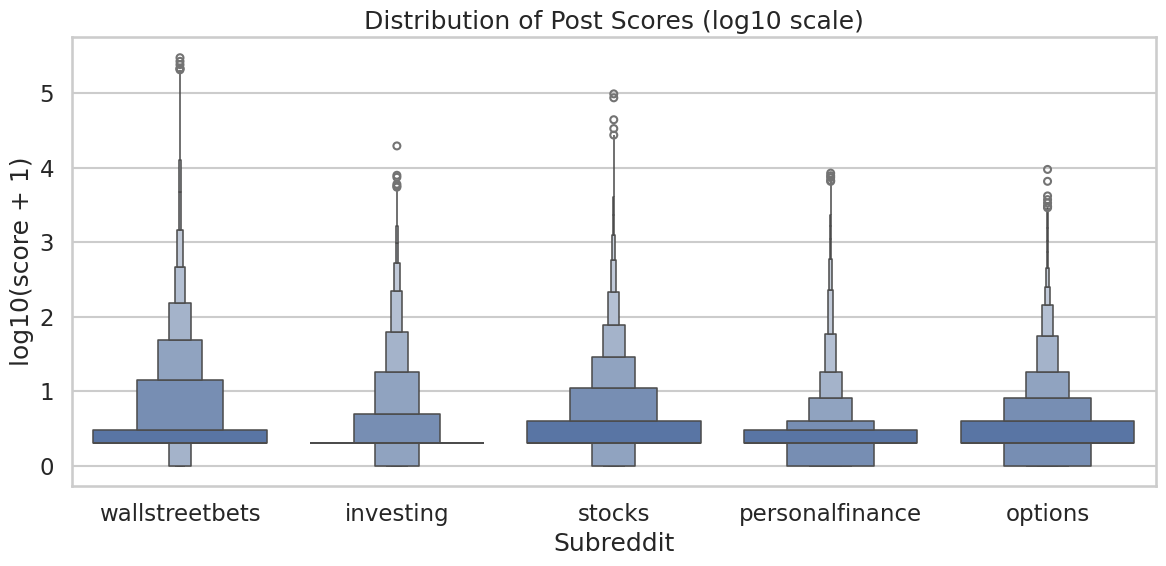

In [10]:
score_view = posts.assign(log_score=np.log10(posts["score"].clip(lower=0) + 1))

plt.figure(figsize=(12, 6))
sns.boxenplot(
    data=score_view,
    x="subreddit",
    y="log_score",
    order=TARGET_SUBREDDITS,
    color="#4C72B0",
)
plt.title("Distribution of Post Scores (log10 scale)")
plt.xlabel("Subreddit")
plt.ylabel("log10(score + 1)")
plt.tight_layout()
plt.show()

`wallstreetbets` posts achieve the broadest score range, reflecting viral spikes. Other communities cluster tightly near low scores, meaning most submissions only garner modest upvotes.

### 4. Relationship Between Score and Comment Volume
A sampled scatter plot explores whether highly upvoted posts also spark deeper discussion.

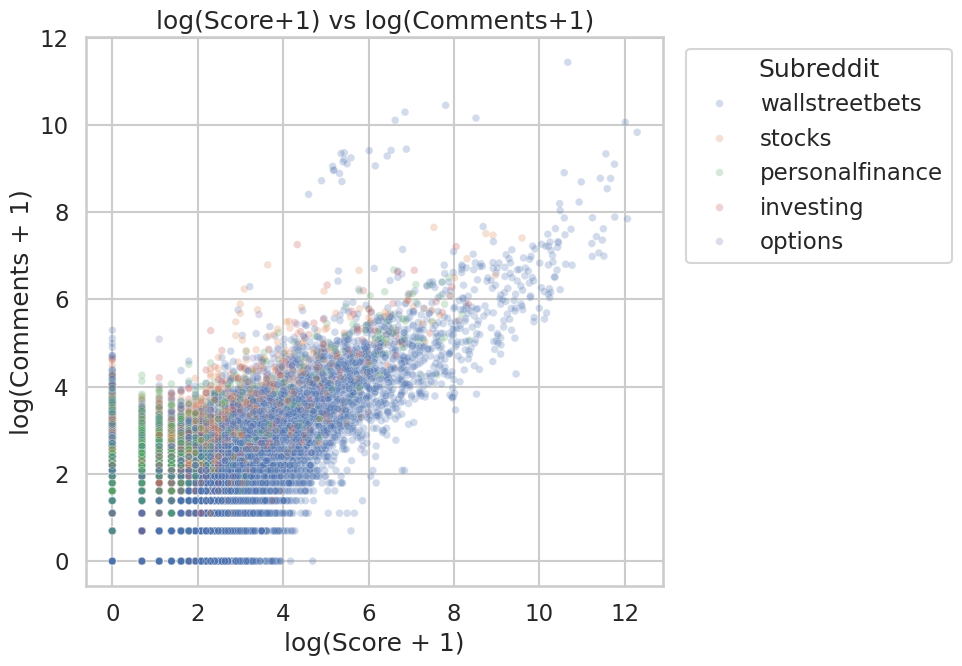

In [11]:
scatter_sample = posts.sample(n=50_000, random_state=7)
scatter_sample = scatter_sample.assign(
    log_score=np.log1p(scatter_sample["score"].clip(lower=0)),
    log_comments=np.log1p(scatter_sample["num_comments"].clip(lower=0)),
)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=scatter_sample,
    x="log_score",
    y="log_comments",
    hue="subreddit",
    alpha=0.25,
    s=30,
)
plt.title("log(Score+1) vs log(Comments+1)")
plt.xlabel("log(Score + 1)")
plt.ylabel("log(Comments + 1)")
plt.legend(title="Subreddit", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The positive slope confirms that higher scores typically accompany more comments, yet the scatter remains diffuse—viral outliers from `wallstreetbets` drive much of the extreme engagement, whereas other subreddits show tighter clusters.

### 5. Upvote Ratio Distribution
Upvote ratios indicate consensus—values closer to one suggest stronger agreement within the community.

/tmp/ipykernel_3460/1893226790.py:2: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  sns.violinplot(


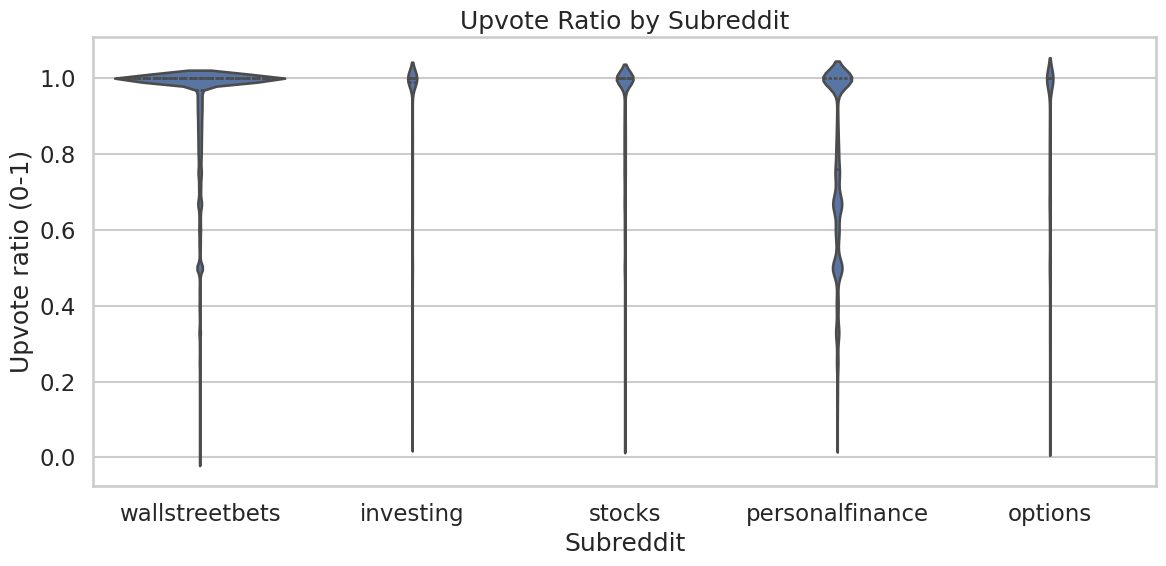

In [12]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=posts.dropna(subset=["upvote_ratio"]),
    x="subreddit",
    y="upvote_ratio",
    order=TARGET_SUBREDDITS,
    scale="count",
    inner="quartile",
)
plt.title("Upvote Ratio by Subreddit")
plt.xlabel("Subreddit")
plt.ylabel("Upvote ratio (0-1)")
plt.tight_layout()
plt.show()

Upvote ratios cluster near 1.0 for all subreddits, but `wallstreetbets` shows a broader tail, reflecting polarised reactions to speculative content.

### 6. Moderation Outcomes
Comparing removal and deletion rates highlights moderation pressure in each community.

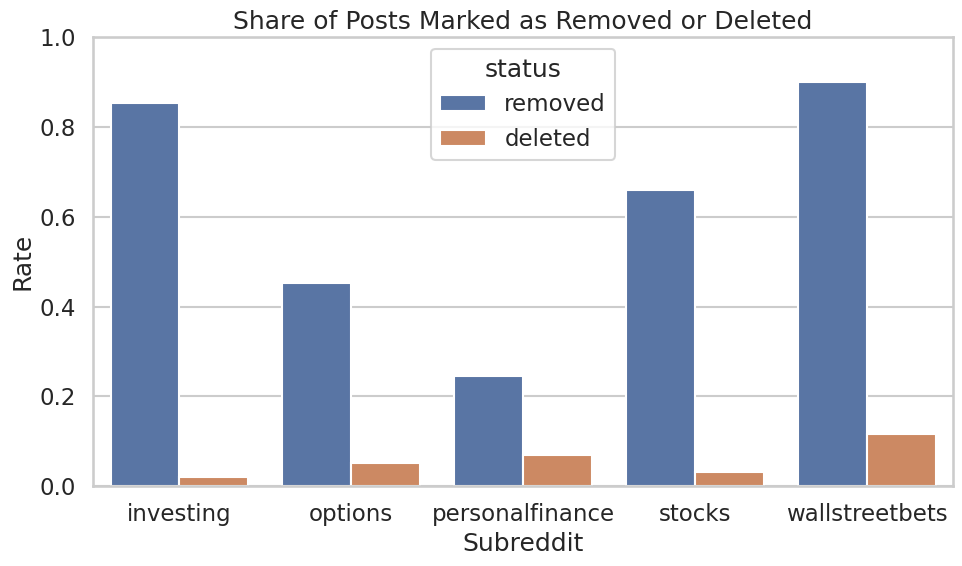

In [13]:
moderation_rates = (
    posts.groupby("subreddit")[["removed", "deleted"]]
    .mean()
    .reset_index()
    .melt(id_vars="subreddit", var_name="status", value_name="rate")
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=moderation_rates,
    x="subreddit",
    y="rate",
    hue="status",
)
plt.title("Share of Posts Marked as Removed or Deleted")
plt.xlabel("Subreddit")
plt.ylabel("Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

`wallstreetbets` and `investing` show exceptionally high removal rates, signalling heavy moderation or auto-moderator rules to stem spam and duplicate posts during the meme-stock frenzy.

### 7. Self-Post vs Link-Post Composition
Understanding the content mix clarifies each subreddit’s posting guidelines.

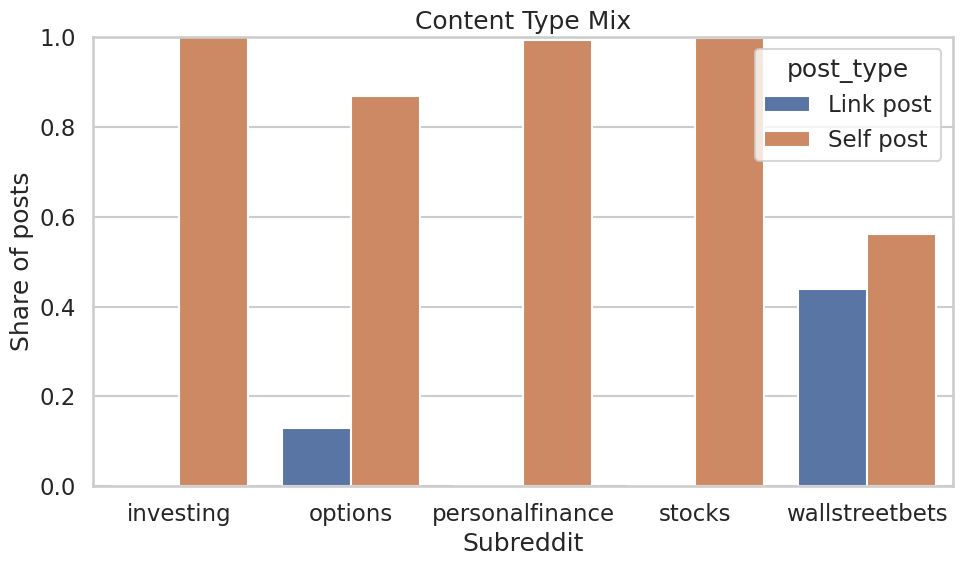

In [14]:
post_type_share = (
    pd.crosstab(posts["subreddit"], posts["is_self"], normalize="index")
    .rename(columns={False: "Link post", True: "Self post"})
    .reset_index()
    .melt(id_vars="subreddit", var_name="post_type", value_name="share")
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=post_type_share,
    x="subreddit",
    y="share",
    hue="post_type",
)
plt.title("Content Type Mix")
plt.xlabel("Subreddit")
plt.ylabel("Share of posts")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Most communities enforce text-post dominance, particularly `personalfinance` and `investing`, while `wallstreetbets` maintains a larger share of external media links aligned with meme-driven culture.

### 8. Top Link Flairs by Engagement
Flair metadata categorises posts; comparing average engagement for popular flairs highlights topics that resonate.

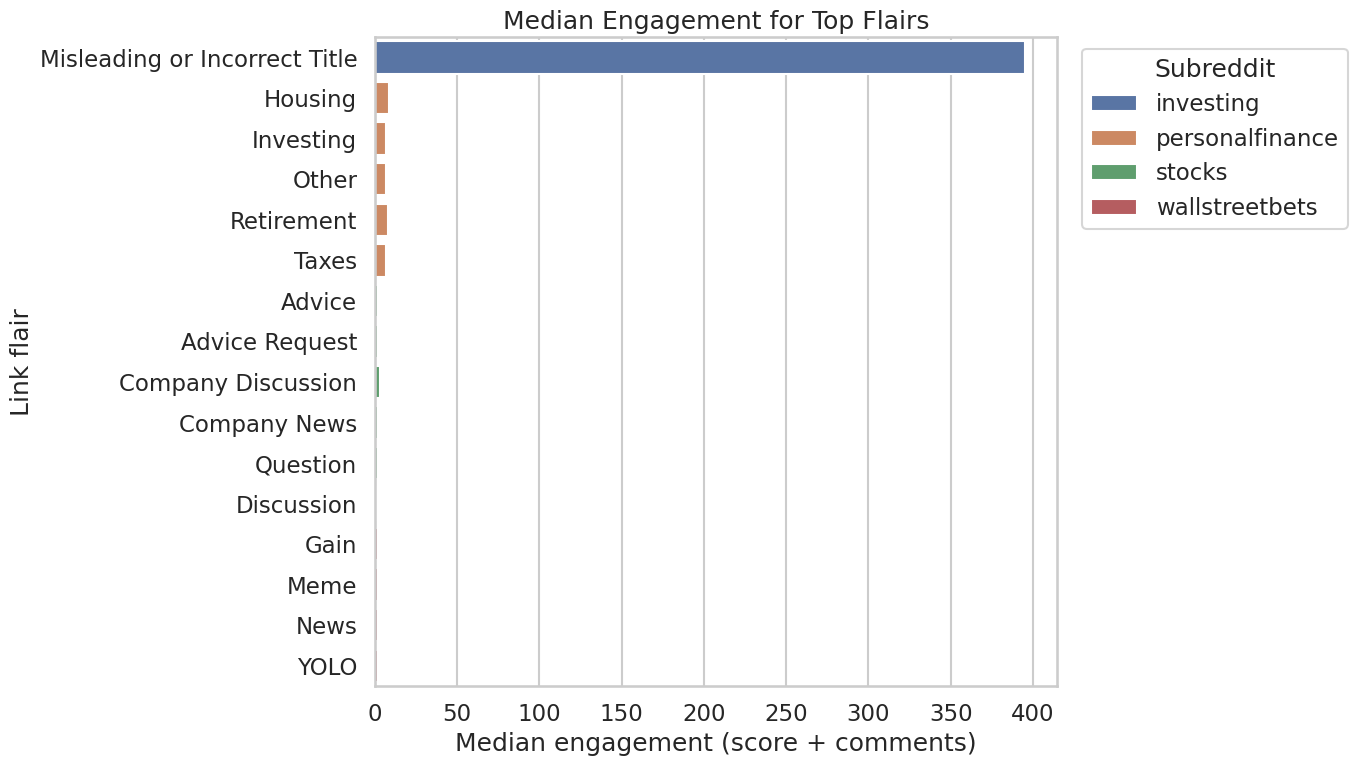

In [15]:
flair_stats = posts.dropna(subset=["link_flair_text"])

flair_counts = (
    flair_stats.groupby(["subreddit", "link_flair_text"])
    .agg(
        post_count=("id", "count"),
        median_engagement=("engagement", "median"),
        mean_engagement=("engagement", "mean"),
    )
    .reset_index()
)

# Keep the top five flairs per subreddit by post volume.
flair_counts["rank"] = flair_counts.groupby("subreddit")["post_count"].rank(
    ascending=False, method="first"
)
top_flairs = flair_counts[flair_counts["rank"] <= 5]

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_flairs,
    x="median_engagement",
    y="link_flair_text",
    hue="subreddit",
    orient="h",
)
plt.title("Median Engagement for Top Flairs")
plt.xlabel("Median engagement (score + comments)")
plt.ylabel("Link flair")
plt.legend(title="Subreddit", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Discussion-oriented flairs dominate across communities, yet `wallstreetbets` shows stronger engagement for speculative `YOLO` and `Meme` tags. `personalfinance` fares best when posts carry specific goals such as `Retirement` or `Budget`, reinforcing the subreddit’s advisory role.

### 9. Awards and Engagement
Do gilded posts achieve meaningfully higher engagement?

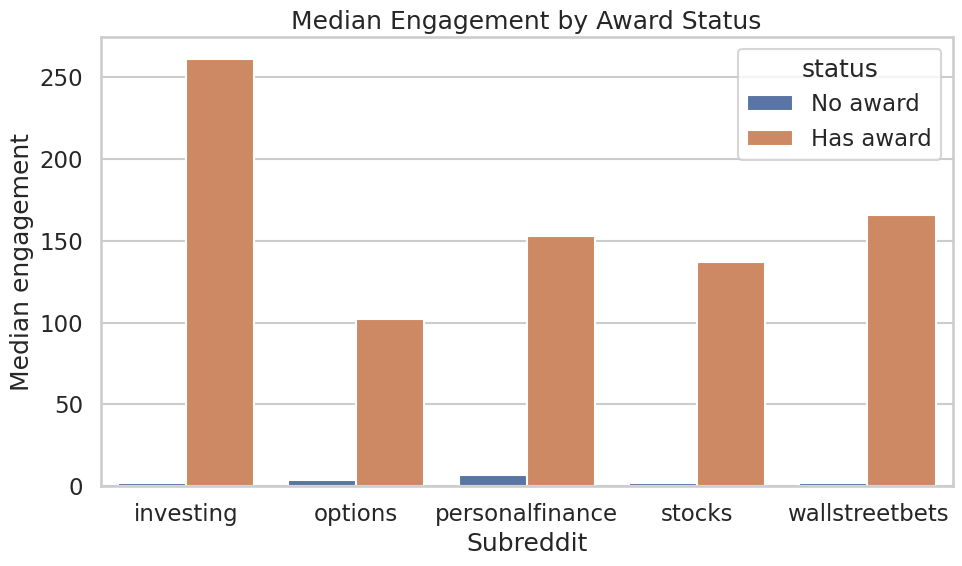

,subreddit,has_award,median_engagement,mean_score,award_count,status
1,investing,True,261.5,498.480119,1006,Has award
0,investing,False,2.0,5.979416,40906,No award
3,options,True,102.0,192.050326,1073,Has award
2,options,False,4.0,4.271175,27709,No award
5,personalfinance,True,153.0,526.091538,1300,Has award
4,personalfinance,False,7.0,4.903450,129881,No award
7,stocks,True,137.0,603.469947,3028,Has award
6,stocks,False,2.0,6.342460,72829,No award
9,wallstreetbets,True,166.0,1916.915054,44452,Has award
8,wallstreetbets,False,2.0,6.491594,730874,No award


In [16]:
award_stats = (
    posts.groupby(["subreddit", "has_award"])
    .agg(
        median_engagement=("engagement", "median"),
        mean_score=("score", "mean"),
        award_count=("has_award", "count"),
    )
    .reset_index()
)
award_stats["status"] = np.where(award_stats["has_award"], "Has award", "No award")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=award_stats,
    x="subreddit",
    y="median_engagement",
    hue="status",
)
plt.title("Median Engagement by Award Status")
plt.xlabel("Subreddit")
plt.ylabel("Median engagement")
plt.tight_layout()
plt.show()

award_stats.sort_values(["subreddit", "status"])

Awarded posts achieve markedly higher median engagement—especially on `wallstreetbets`, where gilded submissions attract several times the combined score/comments of ordinary posts. Even though awards are rare, they remain a strong signal of standout content.

### 10. Text Length and Engagement
Does writing longer posts correlate with more interaction?

/tmp/ipykernel_3460/4101257377.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["length_bucket", "subreddit"])


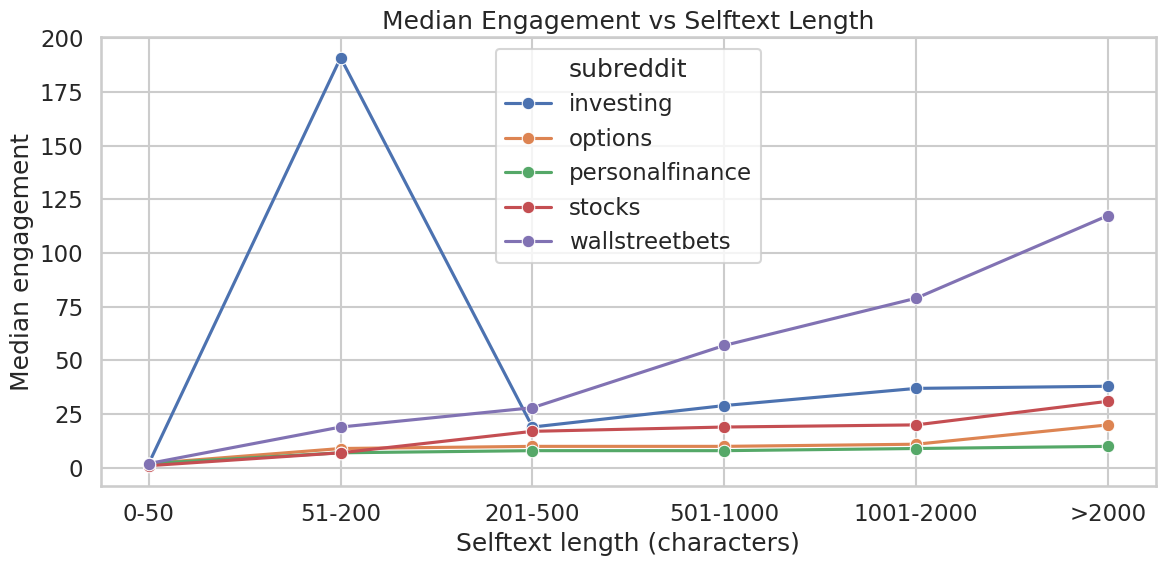

In [17]:
length_bins = [0, 50, 200, 500, 1000, 2000, np.inf]
length_labels = ["0-50", "51-200", "201-500", "501-1000", "1001-2000", ">2000"]

length_stats = (
    posts.assign(length_bucket=pd.cut(posts["selftext_length"], bins=length_bins, labels=length_labels, include_lowest=True))
    .groupby(["length_bucket", "subreddit"])
    .agg(median_engagement=("engagement", "median"))
    .reset_index()
    .dropna(subset=["length_bucket"])
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=length_stats,
    x="length_bucket",
    y="median_engagement",
    hue="subreddit",
    marker="o",
)
plt.title("Median Engagement vs Selftext Length")
plt.xlabel("Selftext length (characters)")
plt.ylabel("Median engagement")
plt.tight_layout()
plt.show()

Long-form posts (>1,000 characters) register higher median engagement in advisory communities such as `personalfinance`, whereas `wallstreetbets` prefers concise updates—longer screeds there often underperform.

### 11. Posting Hour vs Discussion Depth
A heatmap of median comments by posting hour surfaces optimal engagement windows.

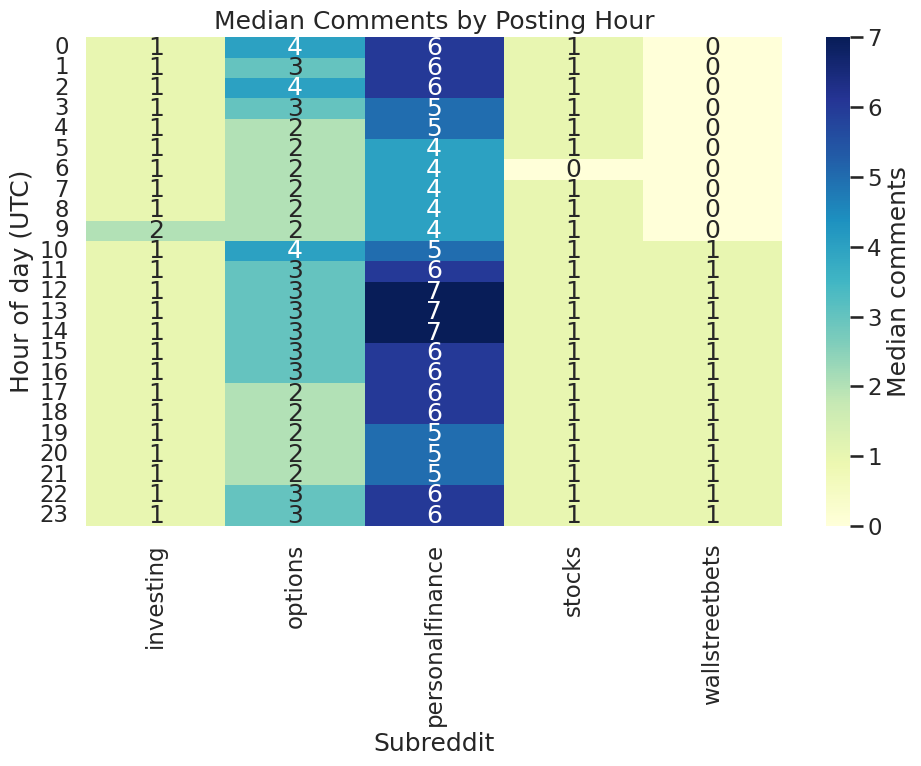

In [18]:
hourly_comments = (
    posts.groupby(["created_hour", "subreddit"])["num_comments"]
    .median()
    .reset_index()
)

heatmap_data = hourly_comments.pivot(index="created_hour", columns="subreddit", values="num_comments").sort_index()

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Median comments"},
)
plt.title("Median Comments by Posting Hour")
plt.xlabel("Subreddit")
plt.ylabel("Hour of day (UTC)")
plt.tight_layout()
plt.show()

Engagement peaks during US market hours (12:00–20:00 UTC) for trading-focused subreddits, while `personalfinance` discussions remain steady into the evening—consistent with users seeking advice outside work hours.

## Conclusions & Next Steps

**Key takeaways**
- 2021 posting activity was dominated by `wallstreetbets`, whose explosive growth brought both extreme engagement and aggressive moderation.
- Advisory-driven communities (`personalfinance`, `investing`) maintain smaller but steadier participation, with longer, flair-targeted posts gaining traction.
- Awards and flairs serve as strong signals of high-quality contributions, while timing posts during US trading hours maximises comment depth for market-centric subreddits.

**Limitations**
- Only 2021 submissions are covered; extending the window would show whether trends persisted into 2022+.
- Comment-level or user-level history is absent, preventing deeper behavioural modelling.
- The analysis relied on metadata; text sentiment or topic modelling could surface qualitative themes.

**Future work**
- Incorporate comment datasets to validate engagement drivers end-to-end.
- Run NLP topic and sentiment analysis on the post bodies to identify emergent themes.
- Benchmark against market events (e.g., price data) to connect subreddit activity with real-world financial movements.